<a href="https://colab.research.google.com/github/fronre/Big_Data_Intero/blob/main/bigdata_intero.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 MapReduce Log Analysis Dashboard

### 📊 Simulation of HTTP Request Analysis using Map → Shuffle → Reduce

#### 👨‍💻 Master 1 IOT | University of Eloued
#### 📅 2025/*2026*

# 📊 Web Log Dataset

This dataset contains HTTP request logs used for MapReduce simulation.

Each record includes:
- Date and Time of the request
- IP address of the client
- HTTP method (GET, POST)
- Requested URL
- HTTP status code (200, 404, 500, etc.)
- Response size in bytes

👉 This data will be processed using the Map → Shuffle → Reduce model
to compute the number of requests per status code.

In [1]:
%%writefile weblogs.txt
# Date, Time, IP, Method, URL, Status, ResponseSize
2026-04-28,12:01:32,192.168.1.2,GET,/index.html,200,1024
2026-04-28,12:01:33,192.168.1.3,GET,/products.html,200,850
2026-04-28,12:01:35,192.168.1.4,GET,/contact.html,404,512
2026-04-28,12:01:38,192.168.1.5,POST,/checkout,500,128
2026-04-28,12:01:41,192.168.1.6,GET,/index.html,200,1024
2026-04-28,12:01:45,192.168.1.7,GET,/images/logo.png,200,256
2026-04-28,12:01:48,192.168.1.8,GET,/about.html,404,512
2026-04-28,12:01:53,192.168.1.9,POST,/login,403,64
2026-04-28,12:02:01,192.168.1.10,GET,/index.html,200,1024
2026-04-28,12:02:07,192.168.1.11,POST,/checkout,500,128
2026-04-28,12:02:12,192.168.1.12,GET,/contact.html,404,512
2026-04-28,12:02:15,192.168.1.13,GET,/index.html,200,1024
2026-04-28,12:02:21,192.168.1.14,GET,/products.html,200,850
2026-04-28,12:02:23,192.168.1.15,GET,/about.html,404,512
2026-04-28,12:02:29,192.168.1.16,POST,/checkout,500,128
2026-04-28,12:02:31,192.168.1.17,GET,/images/logo.png,200,256
2026-04-28,12:02:34,192.168.1.18,GET,/contact.html,404,512
2026-04-28,12:02:38,192.168.1.19,POST,/login,403,64
2026-04-28,12:02:41,192.168.1.20,GET,/index.html,200,1024
2026-04-28,12:02:47,192.168.1.21,GET,/products.html,200,850

Writing weblogs.txt


## ⚙️ MapReduce Processing

In this step, we simulate the MapReduce paradigm:

- The **Map phase** transforms each log entry into key-value pairs (status, 1)
- The **Shuffle phase** groups all identical status codes together
- The **Reduce phase** aggregates the values to compute the total number of requests

🎯 Goal: Analyze HTTP status distribution efficiently.

In [2]:
from collections import defaultdict

def mapper(line):
    fields = line.strip().split(",")
    if len(fields) != 7 or fields[0].startswith('#'):
        return []
    status = fields[5]
    return [(status, 1)]

def shuffle(mapped_data):
    grouped = defaultdict(list)
    for key, value in mapped_data:
        grouped[key].append(value)
    return grouped

def reducer(mapped_data):
    grouped = defaultdict(int)
    for key, value in mapped_data.items():
        grouped[key] = sum(value)
    return grouped

mapped = []

with open("weblogs.txt", "r") as f:
    for line in f:
        mapped.extend(mapper(line))

grouped = shuffle(mapped)
reduced = reducer(grouped)

for code, count in sorted(reduced.items()):
    print(f"HTTP {code}: {count} requests")

HTTP 200: 10 requests
HTTP 403: 2 requests
HTTP 404: 5 requests
HTTP 500: 3 requests


## 🚀 Execution Results

After applying the MapReduce model, we obtain the total number of requests for each HTTP status code.

📊 Results Interpretation:
- HTTP 200 → successful requests
- HTTP 404 → missing pages
- HTTP 500 → server errors
- HTTP 403 → access denied

👉 These results help evaluate system performance and identify potential issues.

In [3]:
from collections import defaultdict

def shuffle(mapped_data):
    grouped = defaultdict(list)
    for key, value in mapped_data:
        grouped[key].append(value)
    return grouped

In [4]:
def reducer(mapped_data):
    grouped = defaultdict(int)
    for key, value in mapped_data.items():
        grouped[key] = sum(value)
    return grouped

In [5]:
mapped = []

with open("weblogs.txt", "r") as f:
    for line in f:
        mapped.extend(mapper(line))

grouped = shuffle(mapped)
reduced = reducer(grouped)

for code, count in sorted(reduced.items()):
    print(f"HTTP {code}: {count} requests")

HTTP 200: 10 requests
HTTP 403: 2 requests
HTTP 404: 5 requests
HTTP 500: 3 requests


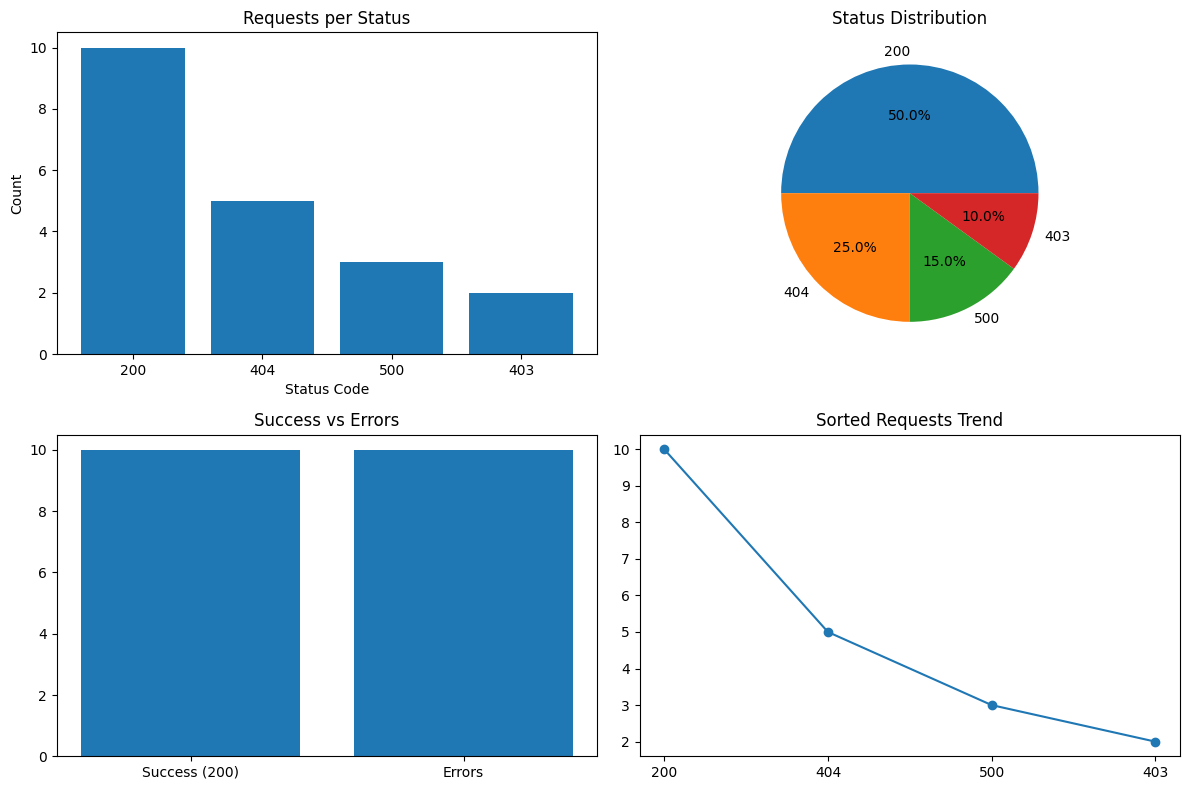

In [6]:
import matplotlib.pyplot as plt

codes = list(reduced.keys())
counts = list(reduced.values())

# حساب success و errors
success = reduced.get("200", 0)
errors = sum(v for k, v in reduced.items() if k != "200")

# إنشاء dashboard (عدة رسومات)
plt.figure(figsize=(12,8))

# 📊 1. Bar Chart
plt.subplot(2,2,1)
plt.bar(codes, counts)
plt.title("Requests per Status")
plt.xlabel("Status Code")
plt.ylabel("Count")

# 🥧 2. Pie Chart
plt.subplot(2,2,2)
plt.pie(counts, labels=codes, autopct='%1.1f%%')
plt.title("Status Distribution")

# ⚖️ 3. Success vs Errors
plt.subplot(2,2,3)
plt.bar(["Success (200)", "Errors"], [success, errors])
plt.title("Success vs Errors")

# 📈 4. Sorted Trend
sorted_items = sorted(reduced.items(), key=lambda x: x[1], reverse=True)
sorted_codes = [k for k,v in sorted_items]
sorted_counts = [v for k,v in sorted_items]

plt.subplot(2,2,4)
plt.plot(sorted_codes, sorted_counts, marker='o')
plt.title("Sorted Requests Trend")

plt.tight_layout()
plt.show()